Demand reconstruction under censoring

We propose a two-step procedure:

* Local interpolation at high temporal resolution, where each station is interpolated independently.

* Global regularization to remove the noise inherent to local estimates, using a low-rank structure
assumption on the hourly demand tensor demand(s,w,d,h)


!pip install ipykernel
!pip install tensorly tqdm scipy pandas
!pip install pyarrow
!pip install matplotlib

In [2]:
import pandas as pd

In [3]:
import pyarrow.dataset as ds

In [4]:
# ============================
# Imports
# ============================
import numpy as np
import tensorly as tl
from tensorly.decomposition import tucker
from tensorly import tucker_to_tensor

from tqdm import tqdm
from scipy.ndimage import gaussian_filter1d
import pandas as pd
import glob
import os

In [5]:
from preprocess import read_metadata, compute_events, apply_censoring, resample_to, gaussian_filter_nan, timeserie

I. Local Interpolation step (Gaussian convolution at high time resolution (minutes))

In [6]:
def local_interpolation(df, min_stock=7, min_ranges=5, time_resolution="2min", kernel_sigma="20min"):
    """
    Orchestrates event computation, censoring, resampling, and local interpolation (gaussian convolution)
    """

    # Step 0: text to numeric
    sigma = pd.Timedelta(kernel_sigma) / pd.Timedelta(time_resolution)
    # Step 1: Compute arrivals, departures, and signals
    df_events = compute_events(resample_to(df, freq=time_resolution))

    # Step 2: Apply censoring logic
    df_censored = apply_censoring(df_events, min_stock=min_stock, min_ranges=min_ranges)


    # Step 4: Recover demand through gaussian convolution nan-filtering
    obs_dep, obs_arr = df_censored["obs_departure"], df_censored["obs_arrival"]
    df_censored["demand"] = gaussian_filter_nan(obs_arr, sigma=sigma) - gaussian_filter_nan(obs_dep,  sigma=sigma)

    # Optionaly: we also store stock, raw flows and censorship mask to remember
    df_censored["raw_flows"] = (obs_arr.astype(float).fillna(0) - obs_dep.astype(float).fillna(0))
    df_censored["censorship"] = (obs_dep+obs_arr).isna().astype(int)


    #final hourly storage
    demand_hourly = df_censored[["demand", "censorship", "raw_flows"]].groupby(df_censored.index.floor("h")).sum()
    demand_hourly["stock"] = df_censored["stock"].groupby(df_censored.index.floor("h")).first()
    return demand_hourly

II. Tensorial Regularisation step (Tucker decomposition on hourly resampled demand)

In [7]:
#here you should find suitable ranks based on the number of stations and weeks to regularize
dummy_rank = [10, 10, 7, 10]

def global_regularisation(demand, rank=dummy_rank):
    """
    Perform global interpolation using Tucker decomposition on demand tensor.
    """
    dem = demand.copy()
    ns, nt = dem.shape

    nw = nt//(168)
    nt = nw*168

    dem_4D = dem[:, :nt].reshape(ns, nw, 7, 24)
    dem_4D = np.asarray(dem_4D, dtype=float)

    # Perform Tucker decomposition
    core, factors = tucker(dem_4D, rank=rank)

    dem[:, :nt] = tucker_to_tensor((core, factors)).reshape(ns, nt)

    return dem

In [8]:
meta = read_metadata()
print(meta.keys())

ns, nh = meta["nstations"], meta["nhours"]

Found 15 stations
Found 13 columns
dict_keys(['stations', 'features', 'begin', 'end', 'nstations', 'nhours'])


In [9]:
demand = np.zeros((ns, nh))
censorship = np.zeros((ns, nh), dtype=bool)
#we keep track of initial demand (raw flows record)
raw_flows = np.zeros((ns, nh))
stock = np.zeros((ns, nh))

for s, st in tqdm(zip(np.arange(ns), meta["stations"]), desc="Loading station data"):
    df = timeserie(st, meta)

    #local interpolation step
    demand_df = local_interpolation(df)
    demand[s] = demand_df["demand"]

    #keep track of censorship just to remind
    censorship[s] = (demand_df["censorship"]>=1)
    raw_flows[s] = demand_df["raw_flows"]
    stock[s] = demand_df["stock"]

Loading station data: 15it [00:11,  1.27it/s]


In [10]:
demand[censorship] = global_regularisation(demand)[censorship]

Here is how our final estimated demand looks

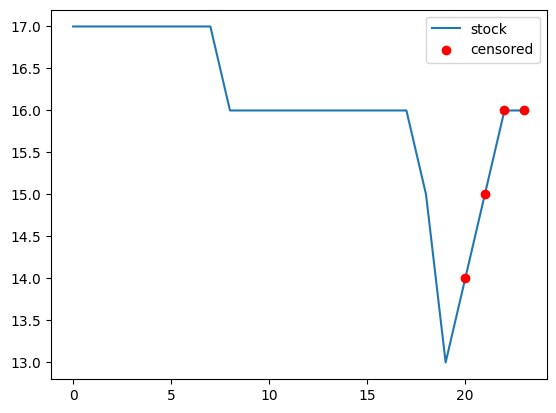

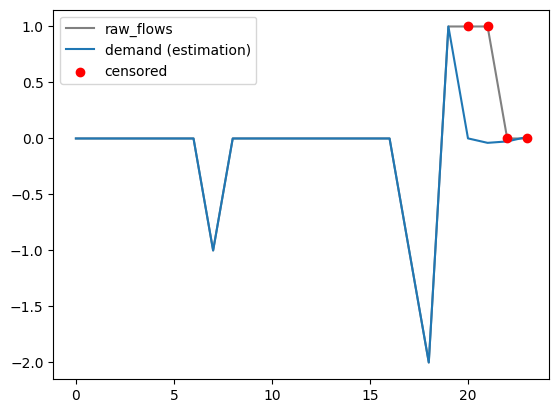

In [16]:
import matplotlib.pyplot as plt
import numpy as np

random_s, random_t = 10, 24
random_times = slice(random_t, random_t + 24)
t = np.arange(random_t)
mask = censorship[random_s, random_times]

plt.figure()
plt.plot(t, stock[random_s, random_times], label="stock")
plt.scatter(
    t[mask],
    stock[random_s, random_times][mask],
    color="red",
    label="censored",
    zorder=3
)
plt.legend()
plt.show()
plt.figure()
plt.plot(t, raw_flows[random_s, random_times], color="grey", label="raw_flows")
plt.plot(t, demand[random_s, random_times], label="demand (estimation)")


plt.scatter(
    t[mask],
    raw_flows[random_s, random_times][mask],
    color="red",
    label="censored",
    zorder=3
)

plt.legend()
plt.show()
